# Regresión con Student Performance

Este cuaderno aplica un modelo de regresión al dataset **Student Performance**. El objetivo es predecir el **índice de desempeño académico** (`Performance Index`) a partir de variables relacionadas con hábitos de estudio y antecedentes del estudiante.

La variable objetivo es numérica continua, por lo tanto, el problema corresponde a **regresión supervisada**.

In [17]:
# Importando las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

# Cargando el dataset
url = "https://raw.githubusercontent.com/Mav432/student-performance/refs/heads/main/Student_Performance.csv"
data = pd.read_csv(url)

data.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [18]:
# Información general del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [19]:
# Revisión de valores nulos
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [20]:
# Estadísticas descriptivas de las variables numéricas
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## Conversión de variable categórica a numérica

La columna `Extracurricular Activities` indica si el estudiante realiza actividades extracurriculares. Como es una variable categórica binaria, se convierte a valores numéricos:

- `No = 0`
- `Yes = 1`

In [21]:
# Conversión de la variable categórica binaria
print(data['Extracurricular Activities'].unique())

data['Extracurricular Activities'] = data['Extracurricular Activities'].map({
    'No': 0,
    'Yes': 1
})

data.head(5)

['Yes' 'No']


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## Separación de variables X y y

Se separan las variables independientes (`X`) de la variable dependiente (`y`).

- `X`: variables predictoras.
- `y`: variable objetivo `Performance Index`.

In [22]:
# Separando los datos en variables de entrada (X) y variable objetivo (y)
X = data.drop('Performance Index', axis=1)
y = data['Performance Index']

print('Tamaño de X:', X.shape)
print('Tamaño de y:', y.shape)

Tamaño de X: (10000, 5)
Tamaño de y: (10000,)


## Entrenamiento del primer modelo

Se divide el dataset en datos de entrenamiento y prueba. Después se entrena un modelo de **Random Forest Regressor**, siguiendo el enfoque del ejemplo de regresión revisado.

In [23]:
# Dividiendo el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Creando el modelo de Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenando el modelo
rf.fit(X_train, y_train)

# Realizando predicciones
_y_pred = rf.predict(X_test)

y_pred = _y_pred

y_pred[:10]

array([56.23      , 22.02333333, 46.41      , 29.52333333, 42.78766667,
       59.715     , 46.78      , 85.986     , 35.86      , 72.01      ])

## Métricas de evaluación

Se calculan las métricas principales de regresión: Error Absoluto Medio (MAE), Error Cuadrático Medio (MSE), Raíz del Error Cuadrático Medio (RMSE), Log RMSE y Coeficiente de Determinación R².

In [24]:
# Calculando métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
log_rmse = np.log(rmse)
r2 = r2_score(y_test, y_pred)

print('Error Absoluto Medio (MAE):', mae)
print('Error Cuadrático Medio (MSE):', mse)
print('Raíz del Error Cuadrático Medio (RMSE):', rmse)
print('Logaritmo de RMSE:', log_rmse)
print('Coeficiente de determinación R²:', r2)

Error Absoluto Medio (MAE): 1.8147207361111108
Error Cuadrático Medio (MSE): 5.158838006796808
Raíz del Error Cuadrático Medio (RMSE): 2.271307554426923
Logaritmo de RMSE: 0.8203556808262994
Coeficiente de determinación R²: 0.9860792088401176


## Cross value score con 5 corridas

Se aplica `cross_val_score` con `cv=5`. Esto significa que se realizan **5 corridas** de validación cruzada, donde en cada corrida se utiliza una partición diferente para evaluación.

In [25]:
# Aplicando cross_val_score con 5 corridas
cross_val_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

for i, score in enumerate(cross_val_scores, start=1):
    print(f'Corrida {i}: R² = {score}')

print('Media de R² con validación cruzada:', np.mean(cross_val_scores))

Corrida 1: R² = 0.9849727582029338
Corrida 2: R² = 0.9848688121255862
Corrida 3: R² = 0.9851878761577408
Corrida 4: R² = 0.9856918837184006
Corrida 5: R² = 0.985006749241372
Media de R² con validación cruzada: 0.9851456158892068


## Cross validate

`cross_validate` permite evaluar el modelo con varias métricas durante la validación cruzada. En este caso se utilizan R², MSE, MAE y RMSE con 5 corridas.

In [26]:
# Definiendo RMSE como métrica
rmse_scorer = make_scorer(
    lambda y_real, y_estimado: np.sqrt(mean_squared_error(y_real, y_estimado)),
    greater_is_better=False
)

# Métricas para validación cruzada
scoring = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'rmse': rmse_scorer
}

# Validación cruzada con 5 corridas
scores = cross_validate(rf, X, y, cv=5, scoring=scoring)

print('R² promedio:', scores['test_r2'].mean())
print('MSE promedio:', -scores['test_mse'].mean())
print('MAE promedio:', -scores['test_mae'].mean())
print('RMSE promedio:', -scores['test_rmse'].mean())

R² promedio: 0.9851456158892068
MSE promedio: 5.479085553076646
MAE promedio: 1.8603121654761903
RMSE promedio: 2.3406604148952


## Comparando dos modelos

Se comparan dos modelos de regresión usando validación cruzada con 5 corridas:

- Random Forest Regressor
- Decision Tree Regressor

In [27]:
# Definiendo los modelos a comparar
modelos = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42)
}

resultados = []

for nombre, modelo in modelos.items():
    scores_modelo = cross_validate(modelo, X, y, cv=5, scoring=scoring)
    resultados.append({
        'Modelo': nombre,
        'R² promedio': scores_modelo['test_r2'].mean(),
        'MSE promedio': -scores_modelo['test_mse'].mean(),
        'MAE promedio': -scores_modelo['test_mae'].mean(),
        'RMSE promedio': -scores_modelo['test_rmse'].mean()
    })

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,R² promedio,MSE promedio,MAE promedio,RMSE promedio
0,Random Forest,0.985146,5.479086,1.860312,2.340660
1,Árbol de Decisión,0.975467,9.047686,2.365683,3.007881


## Corrida independiente para diagramas

Para el diagrama de dispersión y el diagrama de residuos se realiza una **corrida independiente**. Esta corrida usa otra división de entrenamiento y prueba con `random_state=7`, separada de la evaluación anterior.

In [28]:
# Corrida independiente para los diagramas
X_train_graf, X_test_graf, y_train_graf, y_test_graf = train_test_split(
    X, y, test_size=0.2, random_state=7
)

rf_graf = RandomForestRegressor(n_estimators=100, random_state=7)
rf_graf.fit(X_train_graf, y_train_graf)

y_pred_graf = rf_graf.predict(X_test_graf)

## Diagrama de dispersión

El diagrama de dispersión compara los valores reales contra los valores predichos. Si las predicciones fueran perfectas, los puntos quedarían sobre la línea diagonal.

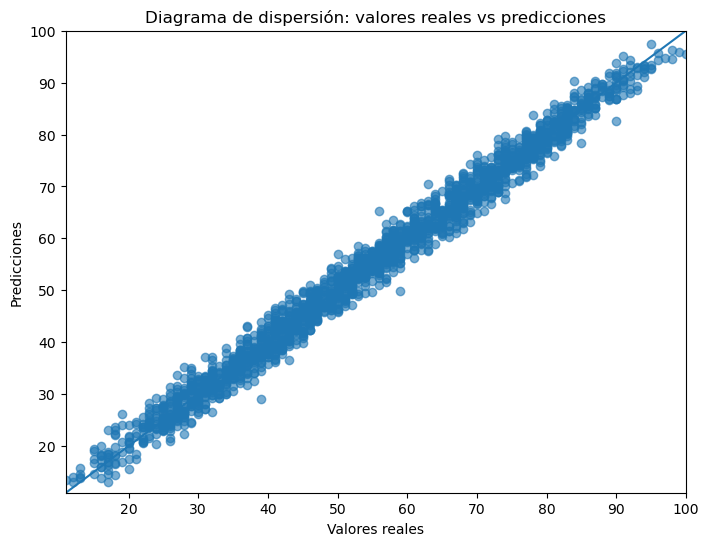

In [29]:
# Diagrama de dispersión: valores reales vs predicciones
plt.figure(figsize=(8, 6))
plt.scatter(y_test_graf, y_pred_graf, alpha=0.6)

lims = [
    min(y_test_graf.min(), y_pred_graf.min()),
    max(y_test_graf.max(), y_pred_graf.max())
]
plt.plot(lims, lims)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Diagrama de dispersión: valores reales vs predicciones')
plt.show()

## Distribución de los residuos

Esta gráfica complementa el análisis de residuos mostrando la frecuencia de los errores del modelo.

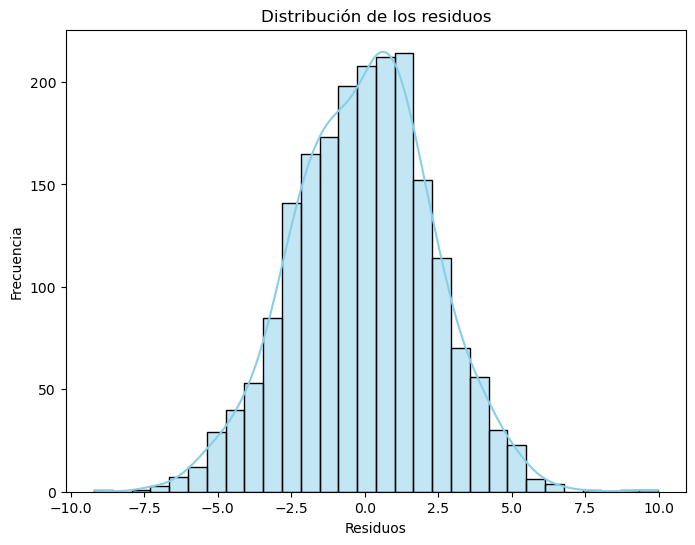

In [30]:
# Histograma de la distribución de los residuos
import seaborn as sns

# Cálculo de residuos de la corrida independiente
residuos = y_test_graf - y_pred_graf

plt.figure(figsize=(8, 6))
sns.histplot(residuos, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de los residuos')
plt.show()

## Exportar modelo

In [31]:
import joblib

# Se guarda el modelo principal entrenado para utilizarlo posteriormente en Flask/Render
joblib.dump(rf, "modelo_regresion.pkl")

['modelo_regresion.pkl']

## Prueba

In [32]:
# Importar modelo guardado para verificar funcionamiento
modelo_cargado = joblib.load("modelo_regresion.pkl")

datos_prueba = pd.DataFrame([{
    "Hours Studied": 7,
    "Previous Scores": 85,
    "Extracurricular Activities": 1,
    "Sleep Hours": 6,
    "Sample Question Papers Practiced": 5
}])

prediccion_prueba = modelo_cargado.predict(datos_prueba)

print("Modelo cargado correctamente.")
print("Predicción de prueba:", prediccion_prueba[0])

Modelo cargado correctamente.
Predicción de prueba: 76.4325
